Eleanor Stoever

AM 170B

Implementing mHAVOK on the Lorenz system

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel
from scipy.integrate import solve_ivp # for SVD
from sklearn.linear_model import LinearRegression # for computing bst fit linear system

# we are implementing mHAVOK manually now, so no need for pydmd's HAVOK

In [5]:
from scipy.integrate import solve_ivp
import numpy as np

# Define Lorenz Function

def generate_lorenz_data(t_eval):

    def lorenz_system(t, state):
        sigma, rho, beta = 10, 28, 8/3

        x, y, z = state

        dxdt = sigma * (y - x)
        dydt = x * (rho - z) - y
        dzdt = x * y - beta * z

        return [dxdt, dydt, dzdt]

    sol = solve_ivp(
        lorenz_system,
        [t_eval[0], t_eval[-1]],
        [-8, 8, 27],
        t_eval=t_eval,
        method="LSODA",
        rtol=1e-12,
        atol=1e-12,
    )

    return sol.y

In [6]:
dt = 0.001
m = 50000

t = np.arange(m) * dt

X = generate_lorenz_data(t)

In [7]:
# Generate Lorenz data
dt = 0.001
m = 50000
t = np.arange(m) * dt
X = generate_lorenz_data(t)

# mHAVOK input channels
# use multiple observables:
Y = X[[0, 2], :]   # channels: x and z
# Y shape = number_of_channels * time

In [8]:
# Build multichannel Hankel matrix
delays = 100

def build_hankel(signal, delays):
    """
    signal is 1D: length m
    returns Hankel delay matrix
    """
    return np.array([
        signal[i : i + len(signal) - delays + 1]
        for i in range(delays)
    ])

H_list = []

for channel in Y:
    H_channel = build_hankel(channel, delays)
    H_list.append(H_channel)

# stack each channel's hankel matrix vertically
H = np.vstack(H_list)

In [9]:
# SVD
U, S, Vh = np.linalg.svd(H, full_matrices=False)

# chose rank (for now, work on better ranking system later)
r = 9

V = Vh[:r, :].T
time_havok = t[:V.shape[0]]

In [10]:
# Regression
# Use first r-1 modes as linear state
# Use last mode as forcing
V_linear = V[:, :r-1]
forcing = V[:, r-1]

# Approximate time derivative
dVdt = np.gradient(V_linear, dt, axis=0)

# Regression input = [linear states, forcing]
Theta = np.column_stack([V_linear, forcing])

model = LinearRegression(fit_intercept=False)
model.fit(Theta, dVdt)

Xi = model.coef_.T

A = Xi[:r-1, :]
B = Xi[r-1:, :]

print("A shape:", A.shape)
print("B shape:", B.shape)

A shape: (8, 8)
B shape: (1, 8)


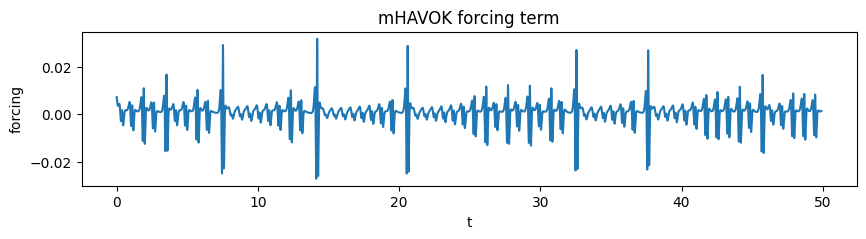

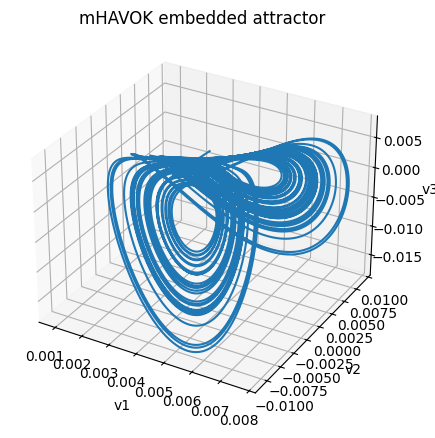

In [11]:
# Plot forcing term
plt.figure(figsize=(10, 2))
plt.plot(time_havok, forcing)
plt.title("mHAVOK forcing term")
plt.xlabel("t")
plt.ylabel("forcing")
plt.show()

# Plot embedded attractor
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(V_linear[:, 0], V_linear[:, 1], V_linear[:, 2])
ax.set_title("mHAVOK embedded attractor")
ax.set_xlabel("v1")
ax.set_ylabel("v2")
ax.set_zlabel("v3")
plt.show()